In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

RACINE = Path.cwd()
while not (RACINE / "src").exists() and RACINE != RACINE.parent:
    RACINE = RACINE.parent
sys.path.append(str(RACINE / "src"))
from train import VARIABLES, charger, decouper

_, _, test = decouper(charger(RACINE / "data" / "processed" / "ventes_features.parquet"))
modele = joblib.load(RACINE / "models" / "lightgbm_final.joblib")
X = test[VARIABLES]
test = test.assign(prediction=modele.predict(X) * test["surface_reelle_bati"])
print(len(test), "ventes de 2025")

4479 ventes de 2025


In [2]:
import shap

explainer = shap.TreeExplainer(modele)
valeurs = explainer(X)
print("Valeur de base (prix au m² moyen du modèle) :", round(float(valeurs.base_values[0])), "€/m²")

Valeur de base (prix au m² moyen du modèle) : 3401 €/m²


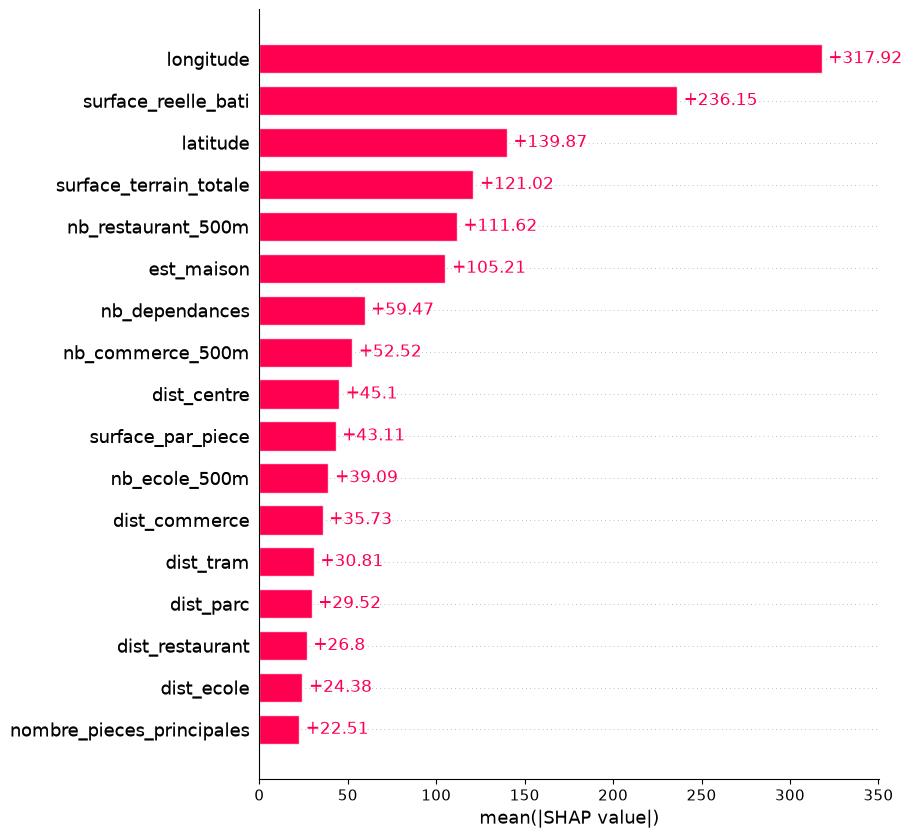

In [3]:
shap.plots.bar(valeurs, max_display=17)

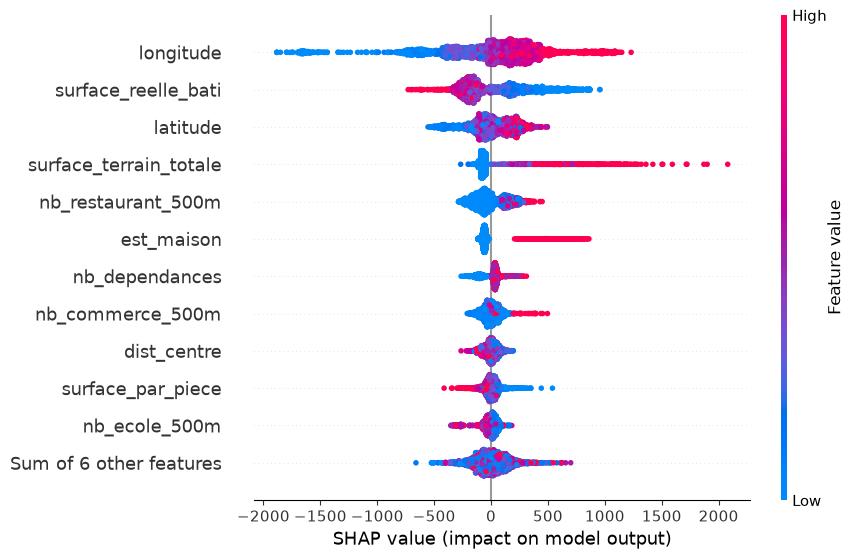

In [4]:
shap.plots.beeswarm(valeurs, max_display=12)

Appartement de 61 m², AV DE LA REGLISSE
Prix réel : 213,200 € — estimation : 196,633 €


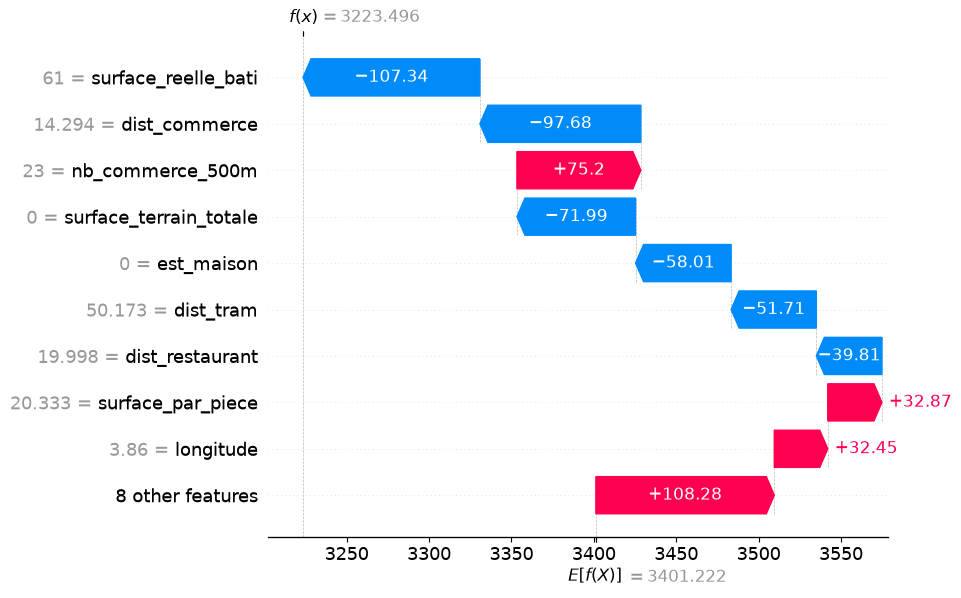

In [5]:
i = 0  # change ce numéro pour explorer d'autres ventes
vente = test.iloc[i]
print(f"{vente['type_local']} de {vente['surface_reelle_bati']:.0f} m², {vente['adresse_nom_voie']}")
print(f"Prix réel : {vente['valeur_fonciere']:,.0f} € — estimation : {vente['prediction']:,.0f} €")
shap.plots.waterfall(valeurs[i], max_display=10)

In [6]:
ratio = test["prediction"] / test["valeur_fonciere"]
print(f"Ratio médian estimation / prix réel : {ratio.median():.3f}")
print("(1,000 = pas de biais ; 1,03 = le modèle surestime de 3 % en général)")


Ratio médian estimation / prix réel : 1.003
(1,000 = pas de biais ; 1,03 = le modèle surestime de 3 % en général)


In [7]:
effet = pd.DataFrame({
    "dist_tram": X["dist_tram"],
    "effet_m2": valeurs[:, "dist_tram"].values,
    "surface": test["surface_reelle_bati"],
})
effet["effet_euros"] = effet["effet_m2"] * effet["surface"]
effet["tranche"] = pd.cut(effet["dist_tram"], [0, 200, 400, 600, 1000, 2000])
effet.groupby("tranche", observed=True)[["effet_m2", "effet_euros"]].median().round(0)

,effet_m2,effet_euros
tranche,,
"(0, 200]",12.0,460.0
"(200, 400]",7.0,347.0
"(400, 600]",-14.0,-811.0
"(600, 1000]",-30.0,-1289.0
"(1000, 2000]",-104.0,-4192.0
